In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
import seaborn as sns
from sklearn.datasets import make_classification, make_blobs, make_moons
from sklearn.decomposition import PCA, TruncatedSVD 
from sklearn.manifold import MDS, Isomap, SpectralEmbedding, LocallyLinearEmbedding, TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
 
from sklearn.cluster import KMeans, DBSCAN
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


import warnings
warnings.filterwarnings('ignore')


try:
    import umap  # pip install umap-learn  
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

In [2]:
# Настройки отображения
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100


In [3]:
from multidim_visualization_for_fruit import HighDimVisualizer

In [4]:
df = pd.read_csv('fruit_classification_dataset.csv')
df

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana
...,...,...,...,...,...,...,...
9995,3.7,round,49.7,72.7,purple,tangy,plum
9996,2.8,oval,18.1,65.5,red,sweet,strawberry
9997,8.7,oval,177.7,72.2,green,sweet,pear
9998,18.0,round,1165.0,107.0,brown,sweet,coconut


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  object 
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  object 
 5   taste          10000 non-null  object 
 6   fruit_name     10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


In [6]:
df['fruit_name'].value_counts()

fruit_name
pomegranate      534
pear             534
pineapple        533
custard apple    516
papaya           509
kiwi             506
blueberry        503
coconut          502
banana           502
lychee           502
mango            500
grape            499
watermelon       498
dragon fruit     496
apple            492
plum             489
orange           487
guava            481
cherry           479
strawberry       438
Name: count, dtype: int64

По заданию нужно выбрать 3-5 классов, по умолчанию берется 3 класса, которые встречаются чаще всего

Классы: ['custard apple' 'papaya' 'pear' 'pineapple' 'pomegranate']

Информация о данных:
  Размер: (2626, 8)
  Количество классов: 5
  Количество признаков: 8
  Минимум: -1.543, Максимум: 2.387
  Среднее: 0.175, Стандартное отклонение: 0.721
ПОЛНАЯ ВИЗУАЛИЗАЦИЯ МНОГОМЕРНЫХ ДАННЫХ

1. Парные диаграммы рассеяния (PairPlot)


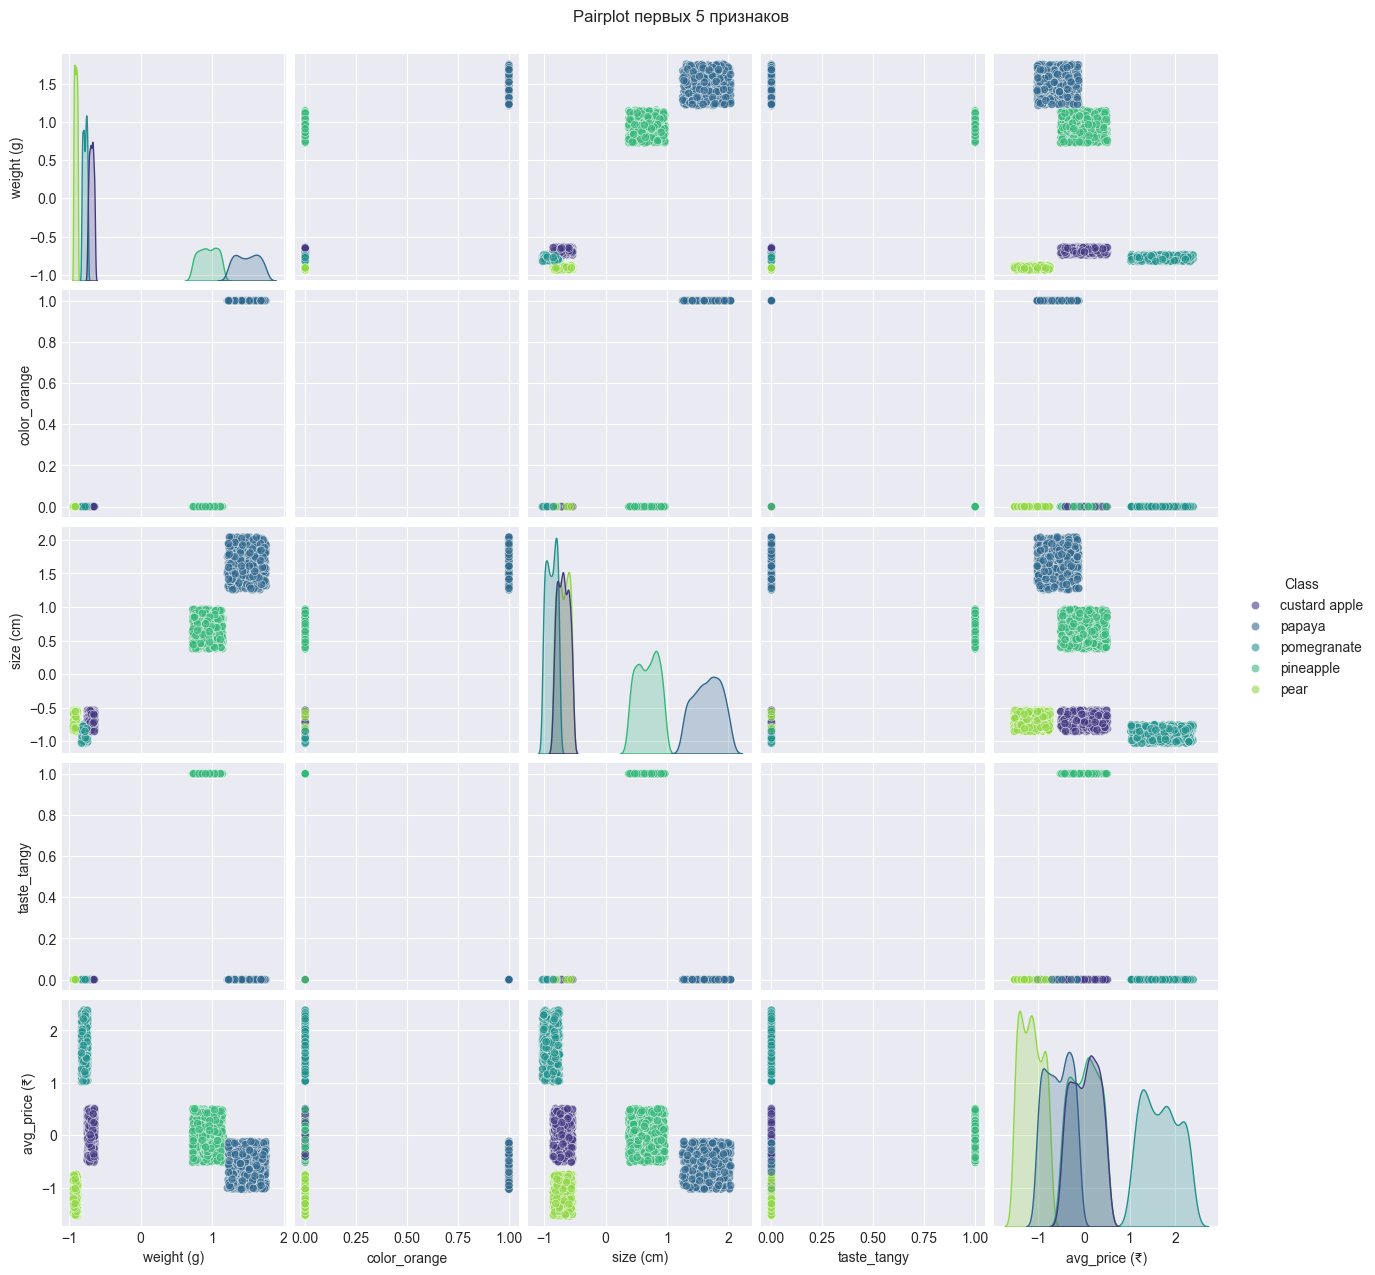


2. Тепловая карта корреляций


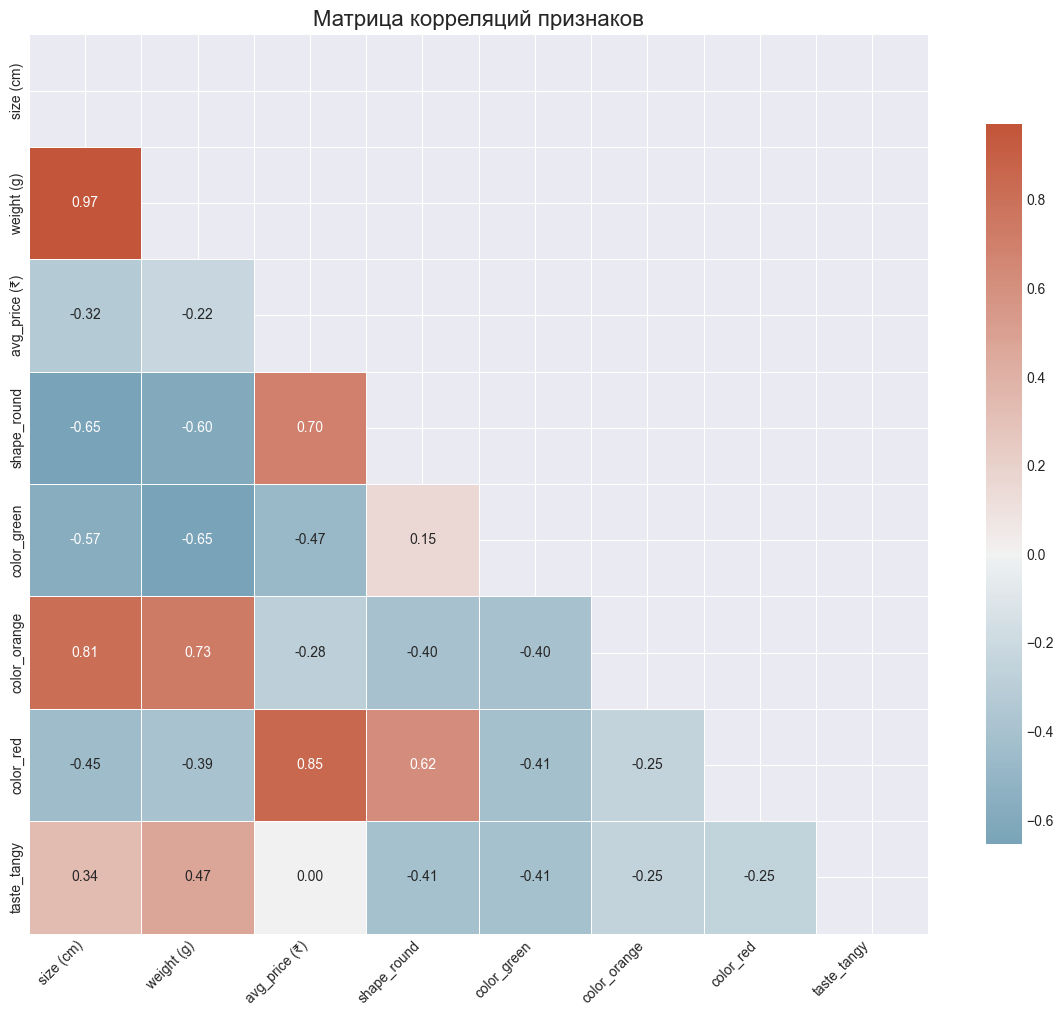


3. Визуализация PCA (2D и 3D)
Объясненная дисперсия: [0.62095609 0.28971716 0.05646763]
Суммарная объясненная дисперсия: 0.967


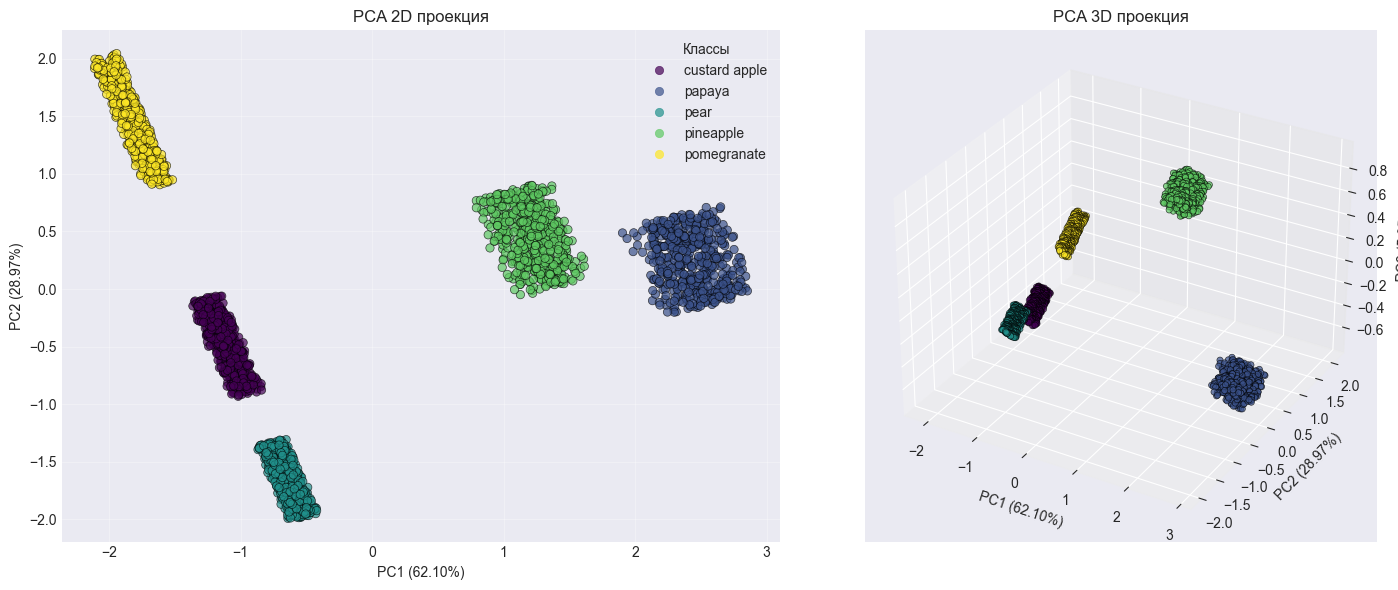

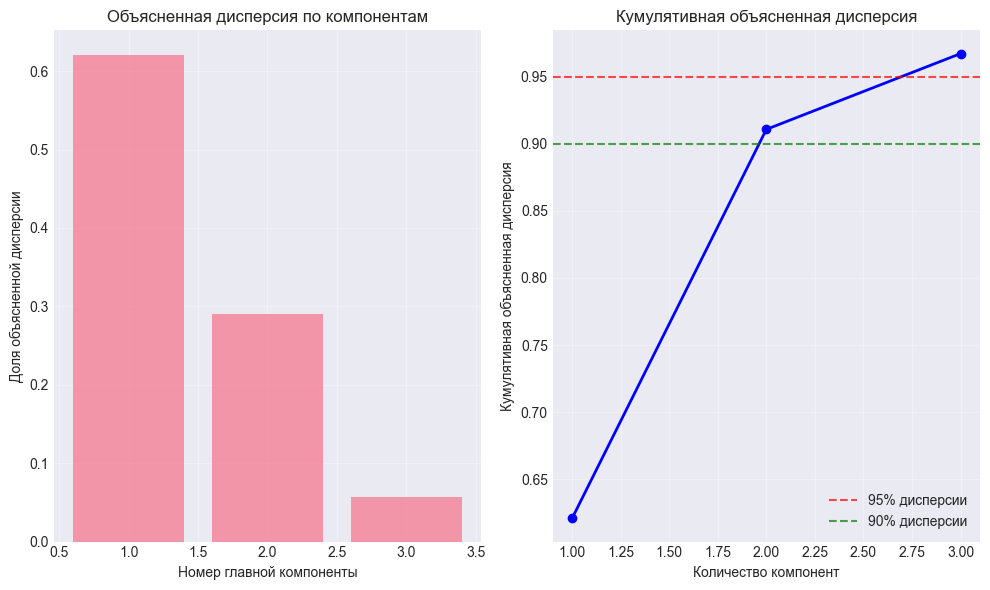


4. Визуализация t-SNE
  Применяем PCA для уменьшения размерности перед t-SNE (8 компонент)...
  Объясненная дисперсия PCA: 1.000
  Вычисляем t-SNE с perplexity=5...
  Вычисляем t-SNE с perplexity=30...
  Вычисляем t-SNE с perplexity=50...


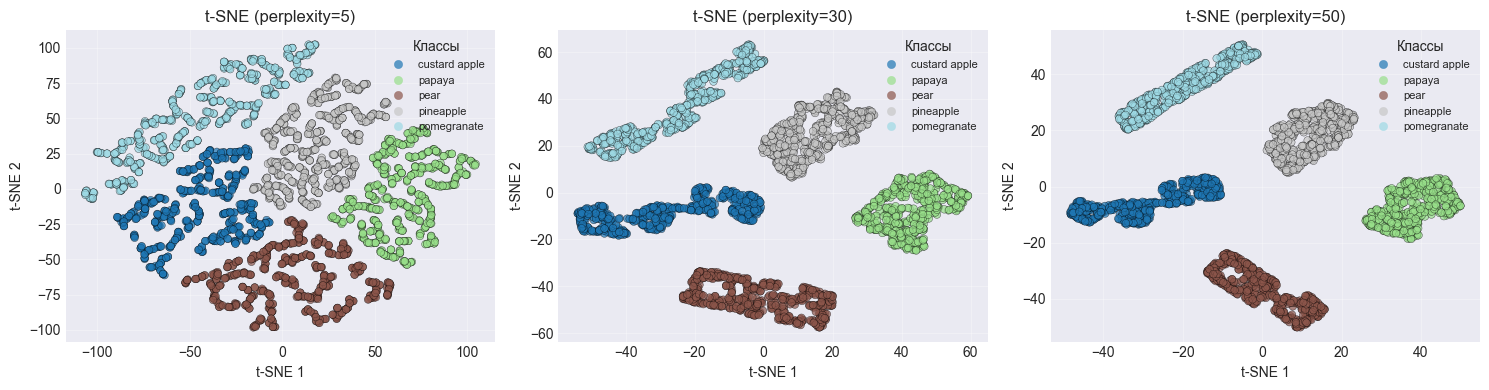


6. Параллельные координаты


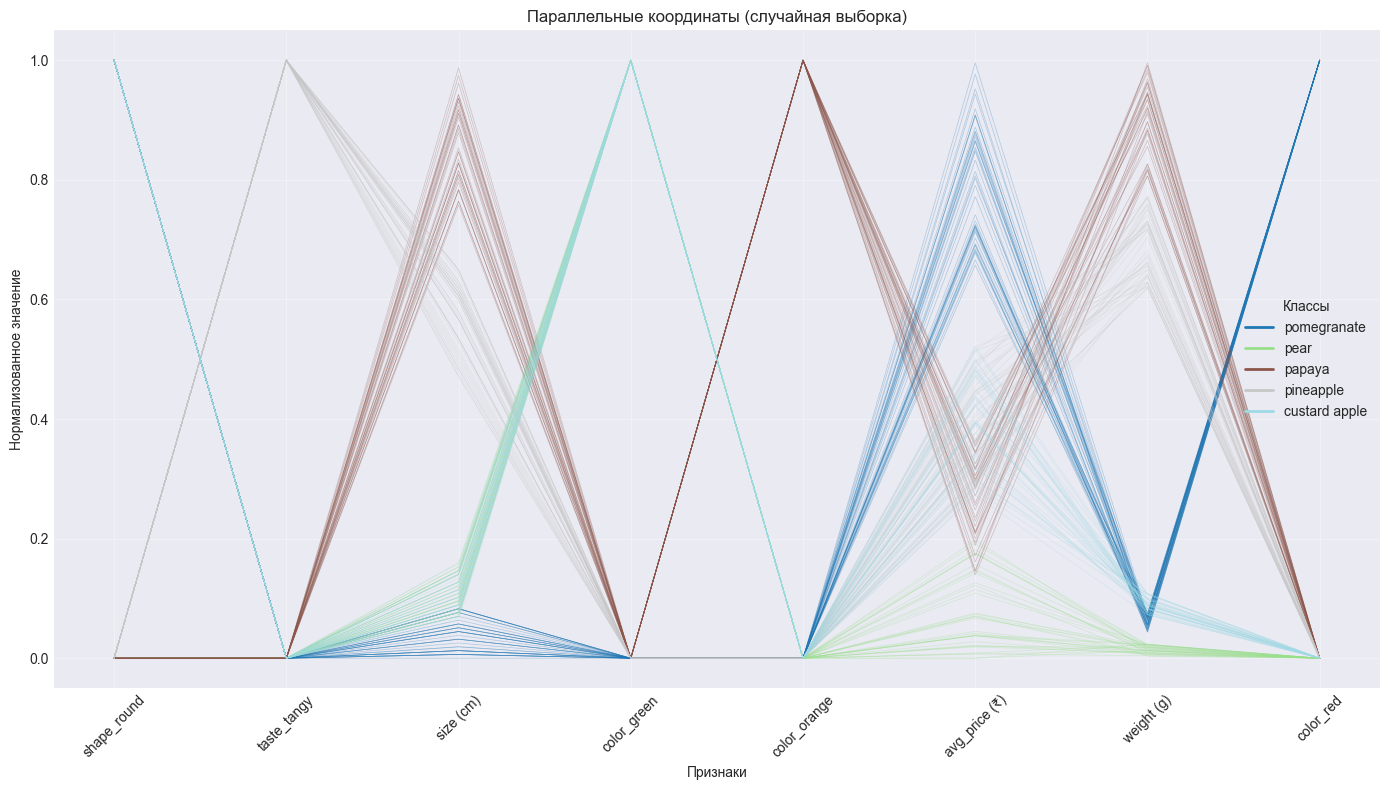


7. Радар-чарты по классам


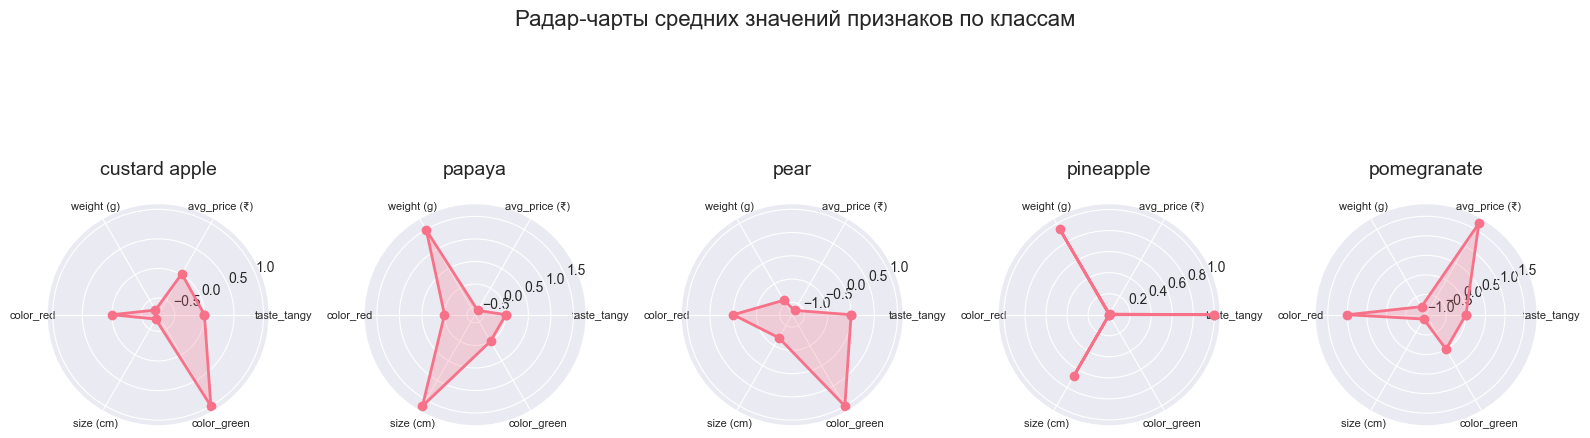


9. Сравнение методов уменьшения размерности
  Применяем PCA...
  Применяем t-SNE...
  Применяем MDS...
  Применяем Isomap...
  Применяем UMAP...


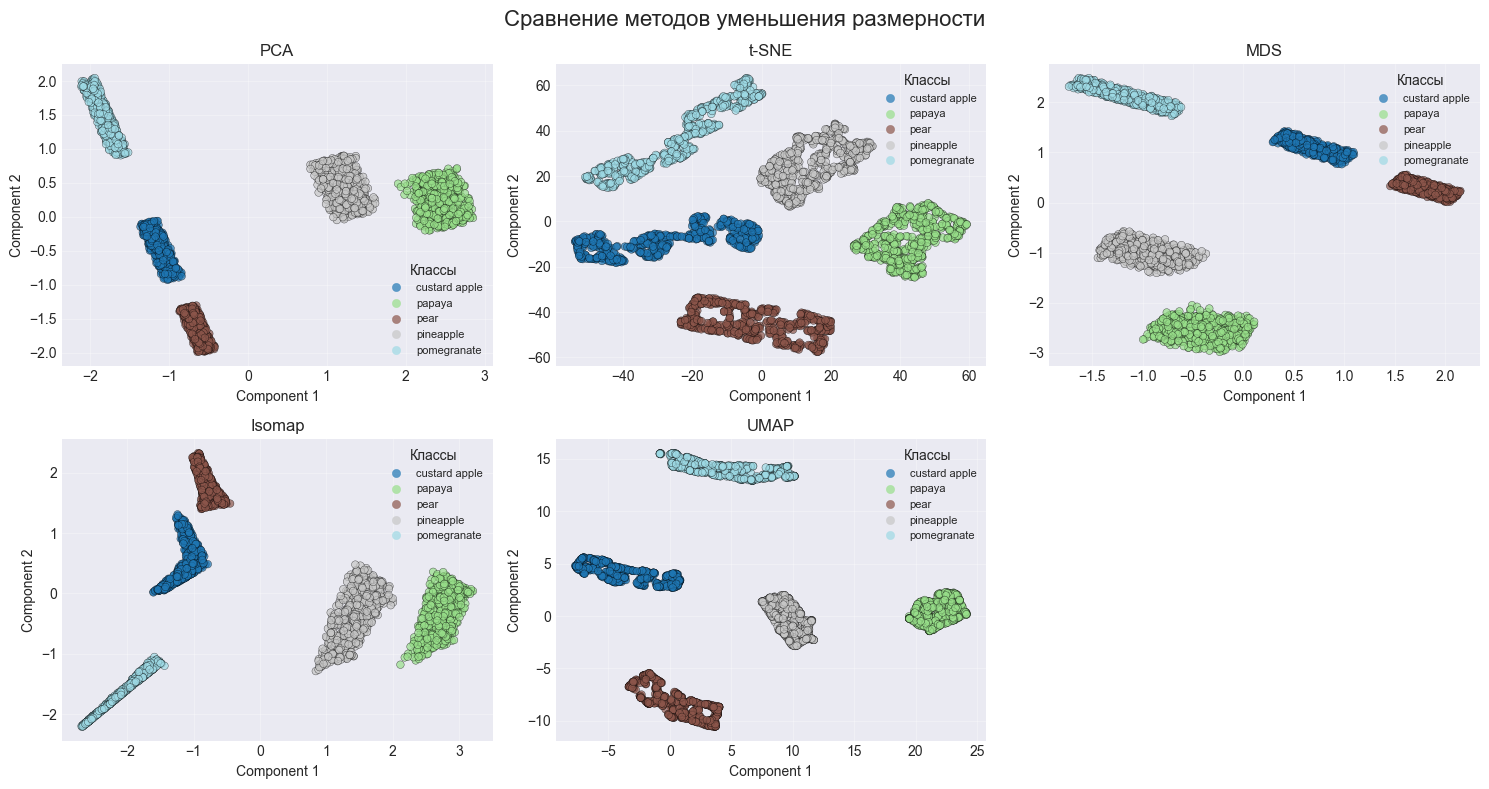


5. Визуализация UMAP


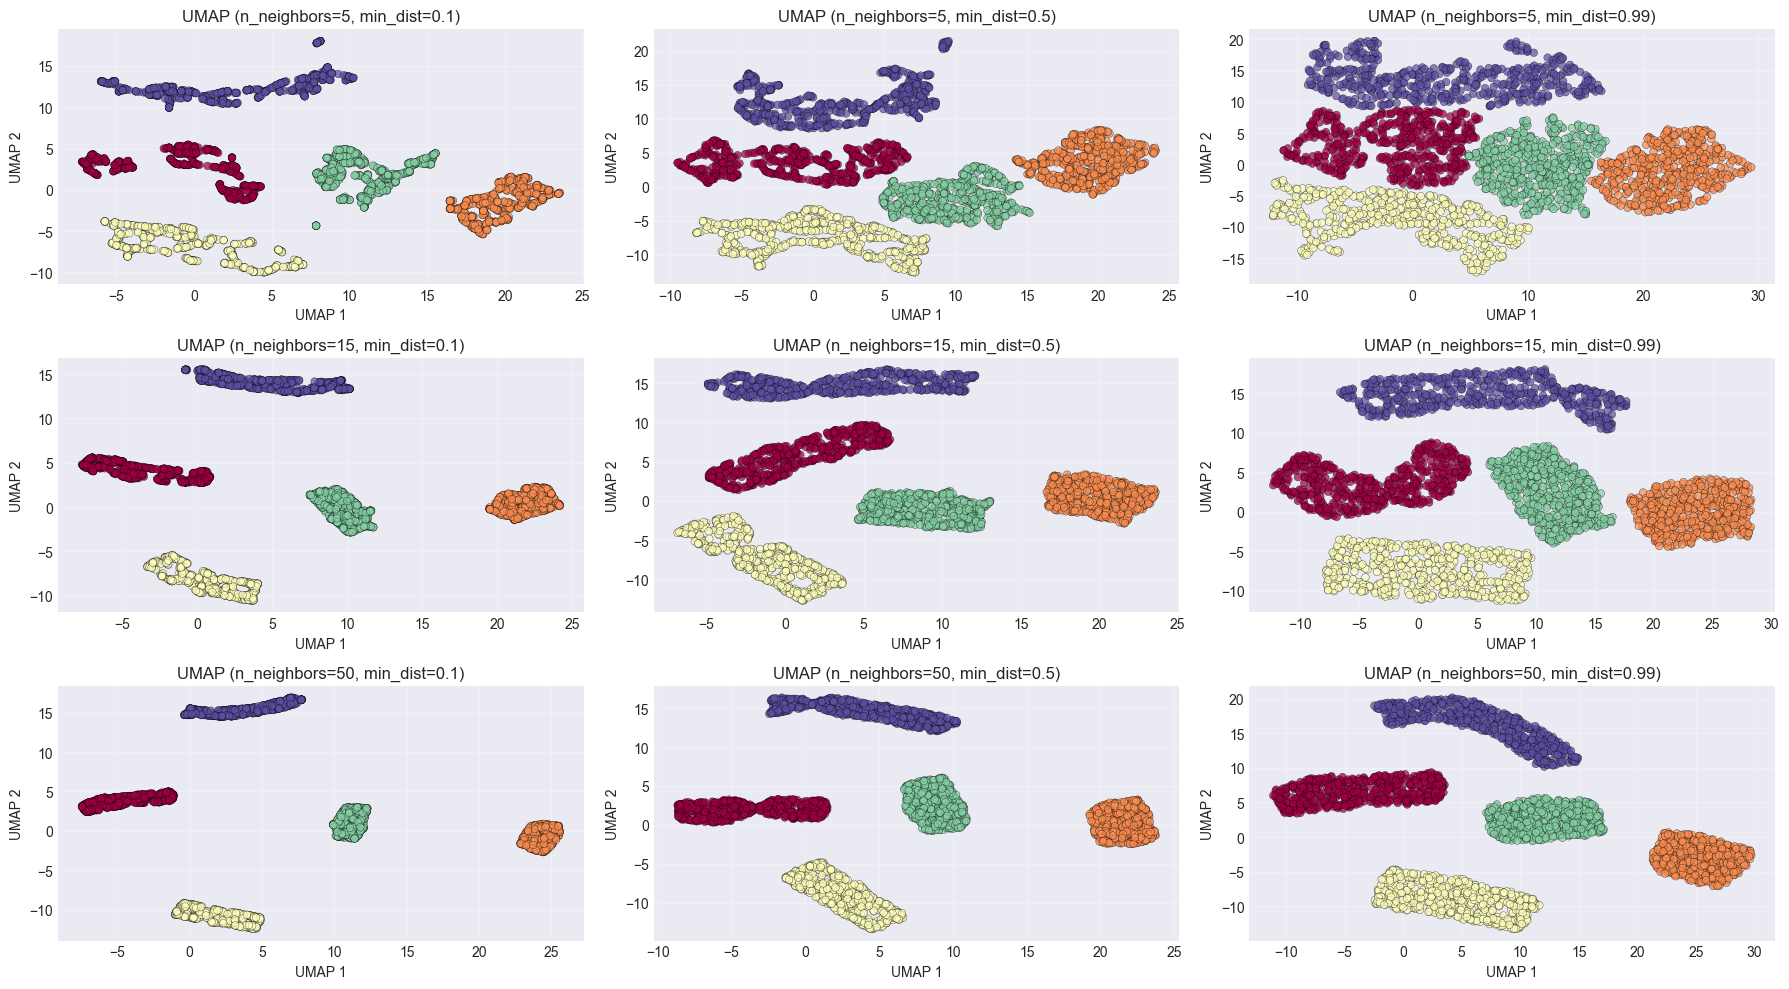


8. Интерактивная 3D визуализация (откроется в браузере)
  График сохранен в файл: interactive_3d_plot.html



ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА


In [7]:
 # Инициализация визуализатора
visualizer = HighDimVisualizer(random_state=42)

X, y, feature_names = visualizer.load_dataset(n_classes=5)

# Базовая информация о данных
print(f"\nИнформация о данных:")
print(f"  Размер: {X.shape}")
print(f"  Количество классов: {len(np.unique(y))}")
print(f"  Количество признаков: {X.shape[1]}")
print(f"  Минимум: {X.min():.3f}, Максимум: {X.max():.3f}")
print(f"  Среднее: {X.mean():.3f}, Стандартное отклонение: {X.std():.3f}")
    
# Запуск визуализации
visualizer.run_full_visualization(X, y, feature_names)